In [1]:
import os
import pickle
import matplotlib.pyplot as plt
import sys
import pandas as pd
internal_MPC_data_dir = os.getcwd()
internal_VTR_dir = os.path.abspath(os.path.join(internal_MPC_data_dir, '..', '..'))
root_dir = os.path.abspath(os.path.join(internal_VTR_dir, '..'))
internal_HT_dir = os.path.abspath(os.path.join(root_dir, '8_Hardware', 'Hardware_Testing'))
internal_HT_MPC_dir = os.path.abspath(os.path.join(internal_HT_dir, '2_MPC_Controllers'))
internal_scripts_dir = os.path.abspath(os.path.join(internal_HT_MPC_dir, 'scripts'))
sys.path.append(internal_scripts_dir)
import H_Common_Params as CP

In [2]:
internal_CDP_data_dir = os.path.abspath(os.path.join(internal_MPC_data_dir, 'Collected_Data_Python'))
print(internal_CDP_data_dir)

d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\April_25\MPC_test_data\Collected_Data_Python


In [3]:
data_list = []
for i in range(len(os.listdir(internal_CDP_data_dir))):
    data_list.append(pd.read_csv(os.path.join(internal_CDP_data_dir, os.listdir(internal_CDP_data_dir)[i])))

In [4]:
data_list[-1].head()

,Ego_Position(m),Ego_Velocity(m/s),Time(s)
0,0.0,0.0,0.000022
1,0.0,0.0,0.055552
2,0.0,0.0,0.167957
3,0.0,0.0,0.279363
4,0.0,0.0,0.392371


In [5]:
def plot(separations, velocities, Dr = CP.Dr_3, Vp = CP.Vp_3, times = None):
    font = 50
    if times is None:
        times = [0.1 * i for i in range(len(separations))]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (60, 25))
    
    plot_separations = [Dr - x for x in separations]
    
    ax1.plot(times, plot_separations, linewidth = 4)
    ax1.plot(times, [CP.Dd + CP.Td * Vp for _ in range(len(plot_separations))], label = f'Desired final seperation', color = 'green', linewidth = 6)
    ax1.grid(True, linewidth = 4)
    ax1.set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    ax1.set_ylabel('Separation [m]', fontsize = font, fontweight = 'bold')
    ax1.set_title(f'[Dr = {Dr}m , Vp = {round(Vp * 18 / 5, 2)}km/hr', fontsize = font, fontweight = 'bold')
    ax1.tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    ax1.legend(fontsize = font)
    
    ax2.plot(times, velocities)
    ax2.plot(times, [Vp * 18 / 5 for _ in range(len(velocities))], label = f'Desired final velocity', color = 'green', linewidth = 6)
    ax2.grid(True, linewidth = 4)
    ax2.set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    ax2.set_ylabel('Velocity [km/hr]', fontsize = font, fontweight = 'bold')
    ax2.set_title(f'[Dr = {Dr}m , Vp = {round(Vp * 18 / 5, 2)}km/hr', fontsize = font, fontweight = 'bold')
    ax2.tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    ax2.legend(fontsize = font)
    
    plt.show()

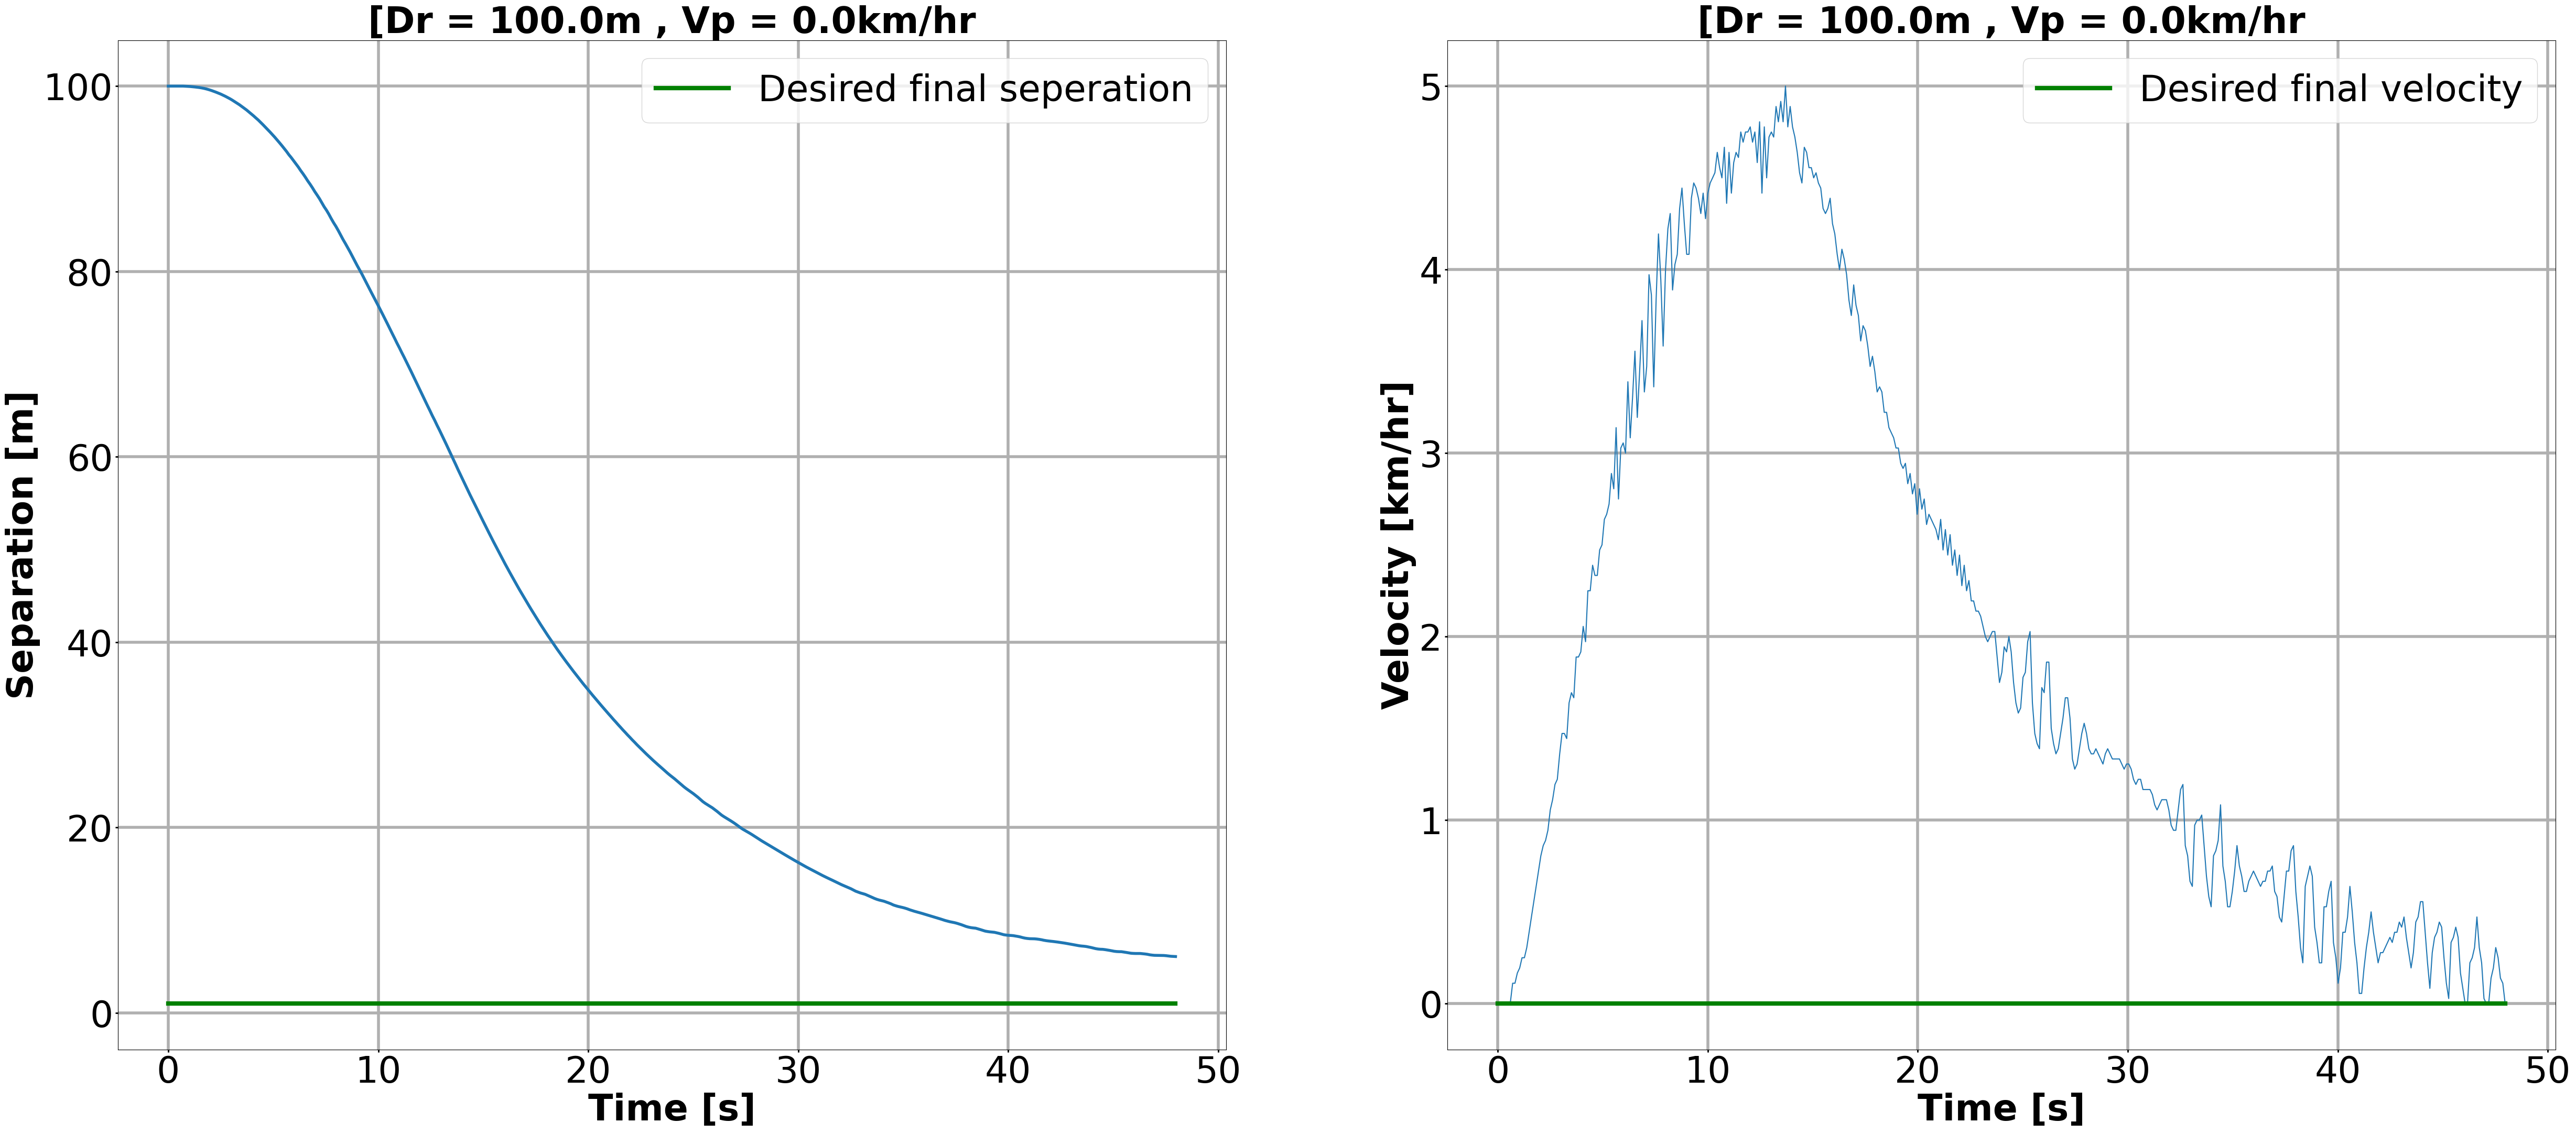

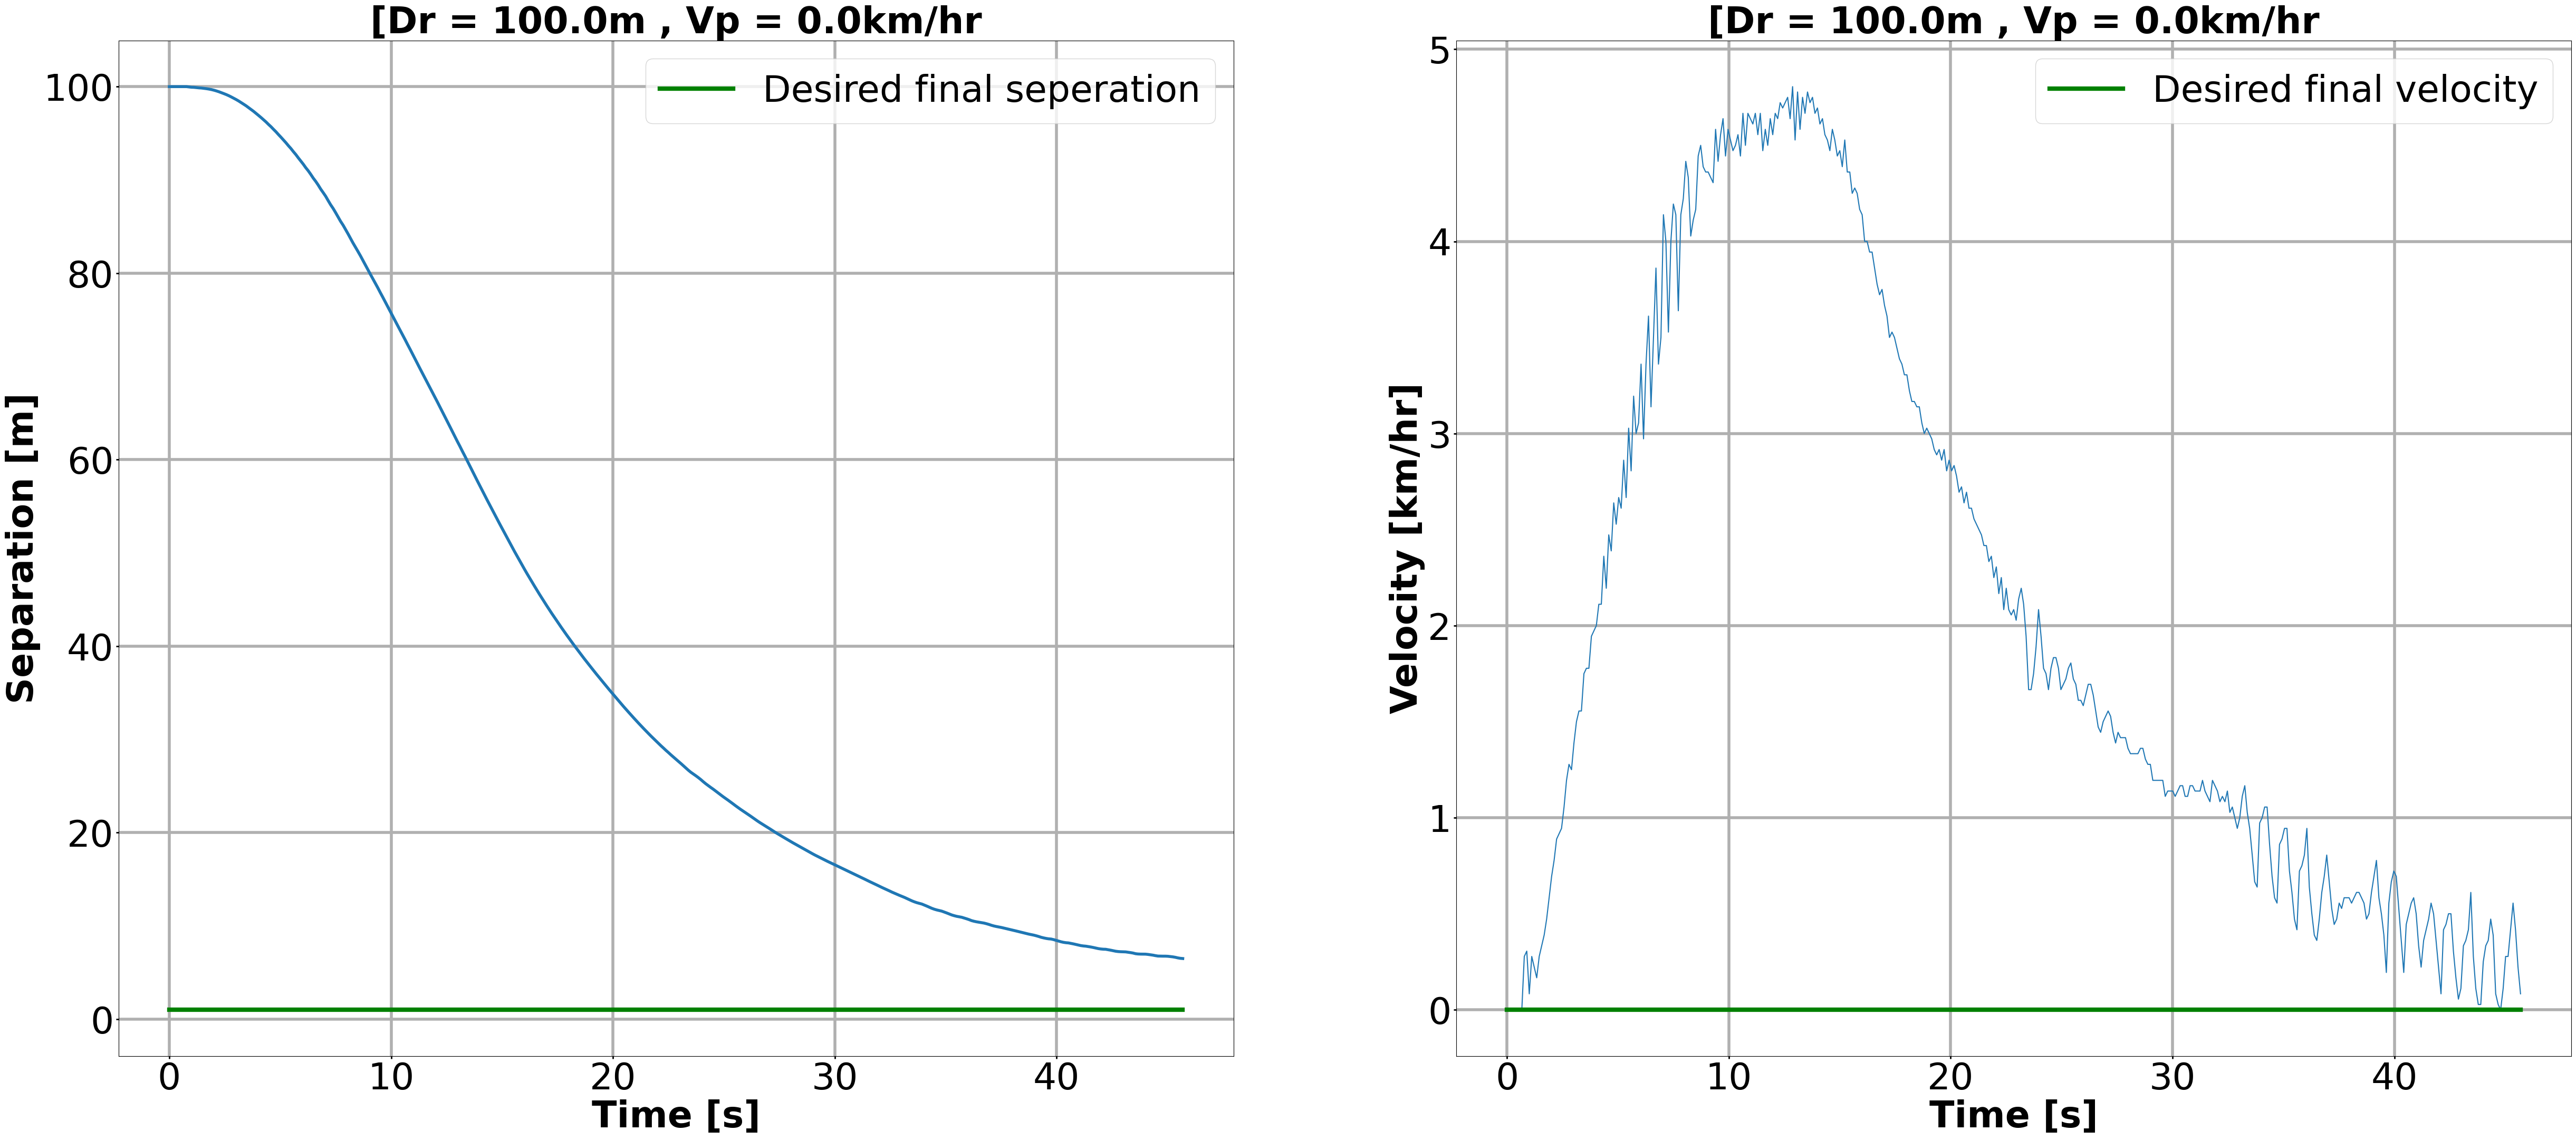

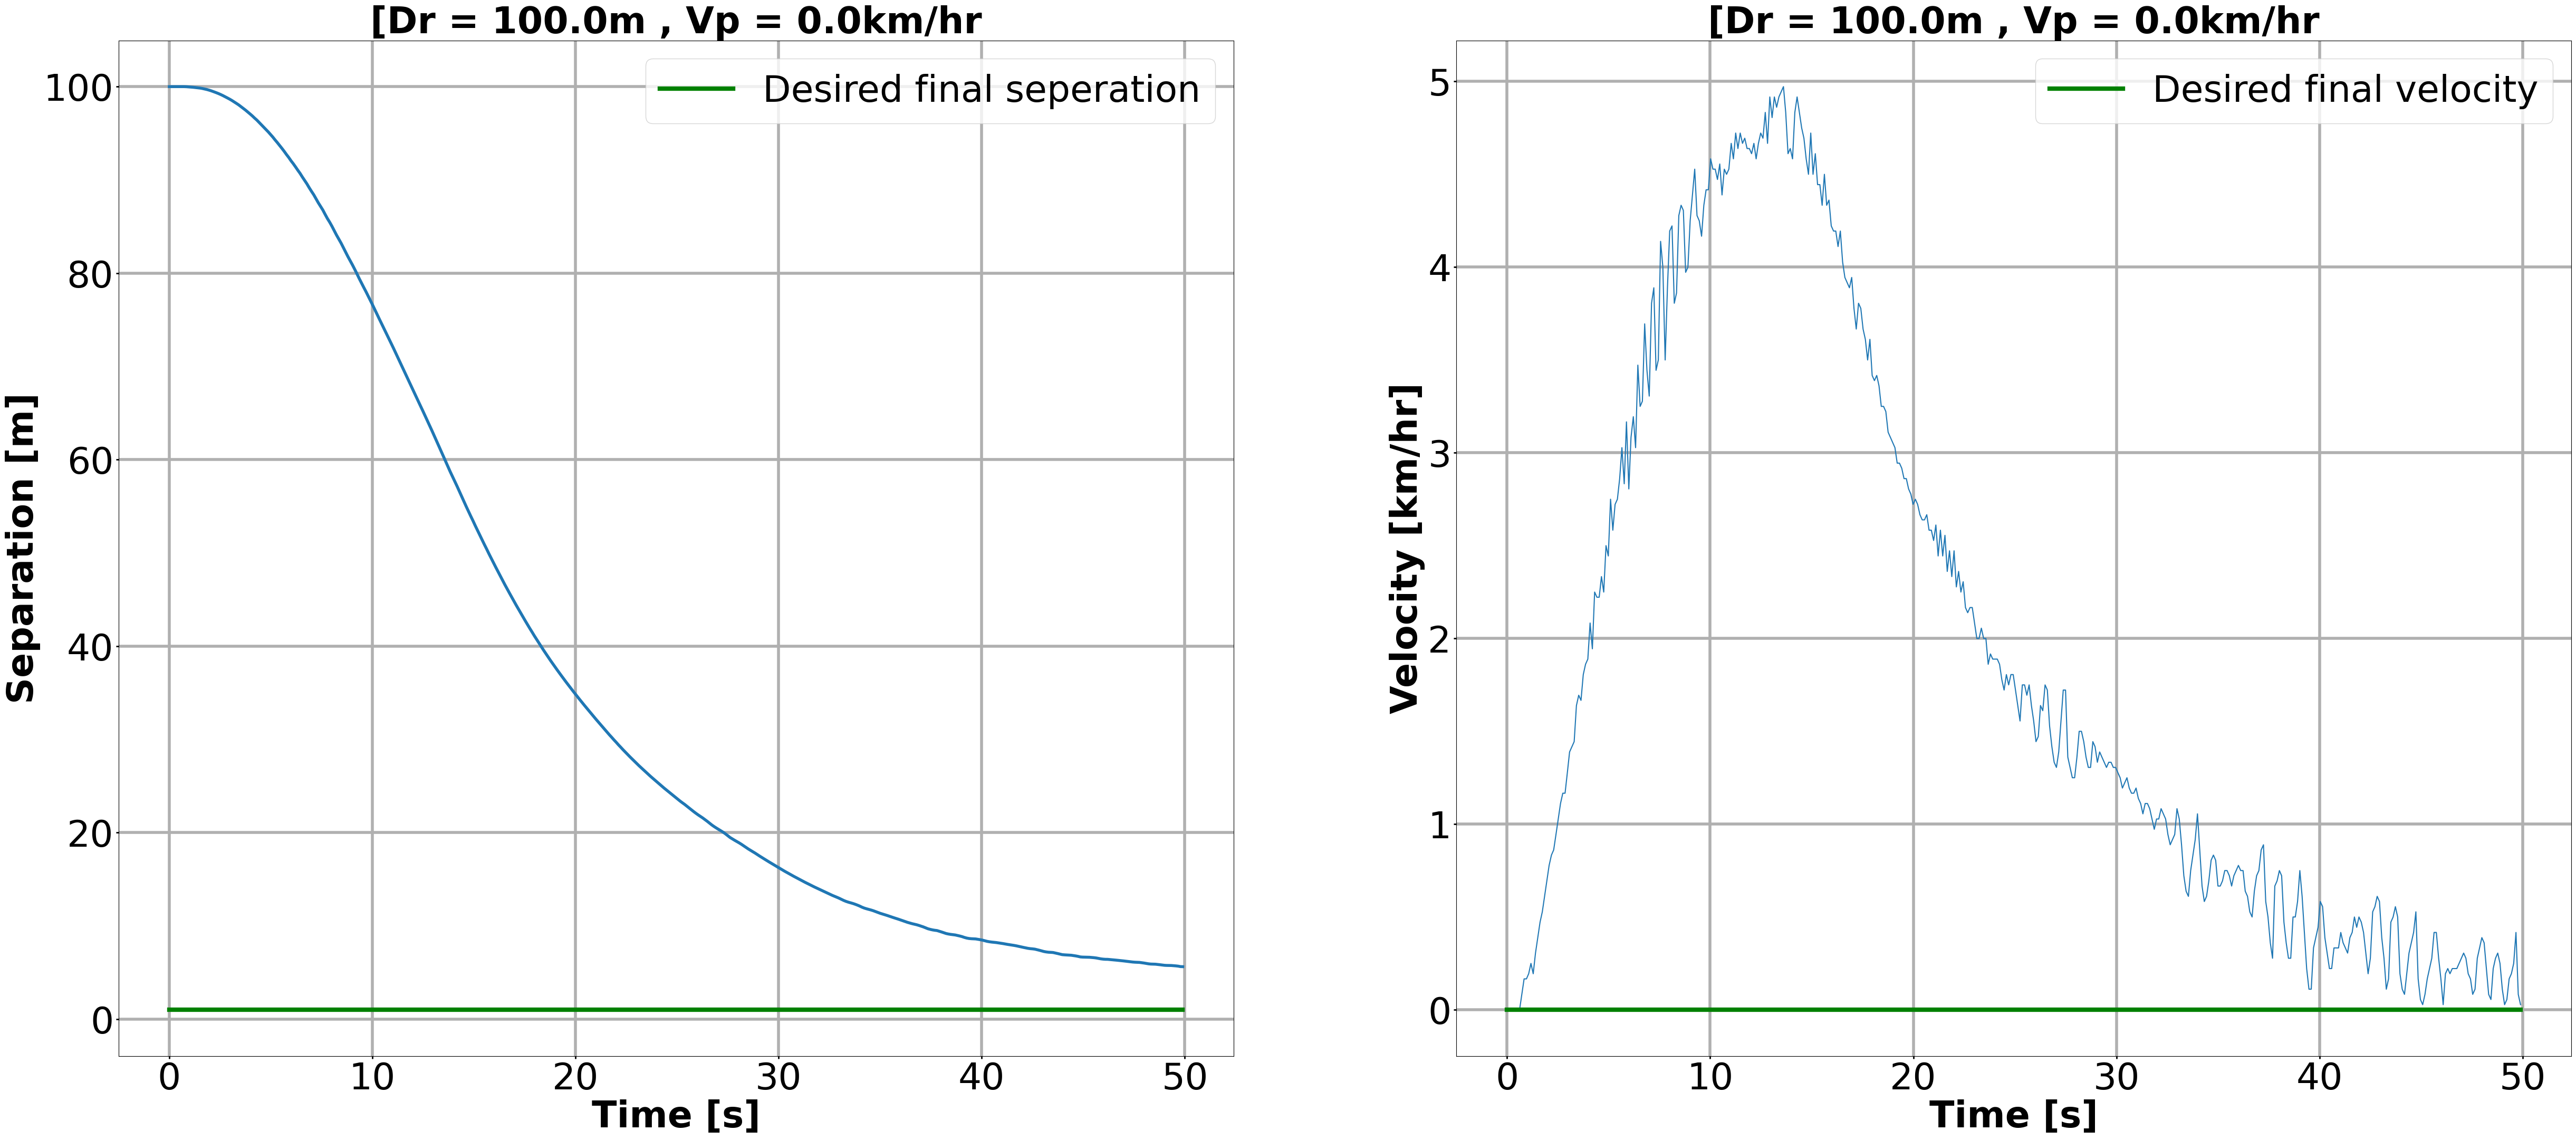

In [7]:
for i in range(len(data_list)):
    plot(data_list[i]['Ego_Position(m)'], data_list[i]['Ego_Velocity(m/s)'], times = data_list[i]['Time(s)'])